In [17]:
from google.colab import files

uploaded = files.upload()

Saving store-sales-time-series-forecasting.zip to store-sales-time-series-forecasting (1).zip


In [18]:
import zipfile

with zipfile.ZipFile("store-sales-time-series-forecasting.zip", "r") as zip_ref:
    zip_ref.extractall("store_sales")

In [19]:
import os

os.listdir("store_sales")

['stores.csv',
 'train.csv',
 'oil.csv',
 'holidays_events.csv',
 'test.csv',
 'transactions.csv',
 'sample_submission.csv']

In [20]:
import pandas as pd

train = pd.read_csv("store_sales/train.csv")

print("Shape:", train.shape)
train.head()

Shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [21]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [22]:
train["date"] = pd.to_datetime(train["date"])

train["date"].min(), train["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [23]:
print(train.columns.tolist())
print("\nData types:\n")
print(train.dtypes)

['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

Data types:

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object


In [24]:
missing = train.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [25]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [26]:
stores = pd.read_csv("store_sales/stores.csv")
transactions = pd.read_csv("store_sales/transactions.csv")
holidays = pd.read_csv("store_sales/holidays_events.csv")
oil = pd.read_csv("store_sales/oil.csv")

print("Stores:", stores.shape)
print("Transactions:", transactions.shape)
print("Holidays:", holidays.shape)
print("Oil:", oil.shape)

Stores: (54, 5)
Transactions: (83488, 3)
Holidays: (350, 6)
Oil: (1218, 2)


In [27]:
train["sales"].describe()

,sales
count,3.000888e+06
mean,3.577757e+02
std,1.101998e+03
min,0.000000e+00
25%,0.000000e+00
50%,1.100000e+01
75%,1.958473e+02
max,1.247170e+05


In [28]:
print("Number of stores:", train["store_nbr"].nunique())
print("Number of product families:", train["family"].nunique())

print("\nProduct families:")
print(train["family"].unique())

Number of stores: 54
Number of product families: 33

Product families:
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [29]:
print("Promotion values:")
print(train["onpromotion"].describe())

print("\nTotal promoted records:", (train["onpromotion"] > 0).sum())

Promotion values:
count    3.000888e+06
mean     2.602770e+00
std      1.221888e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.410000e+02
Name: onpromotion, dtype: float64

Total promoted records: 611329


In [30]:
daily_sales = (
    train.groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


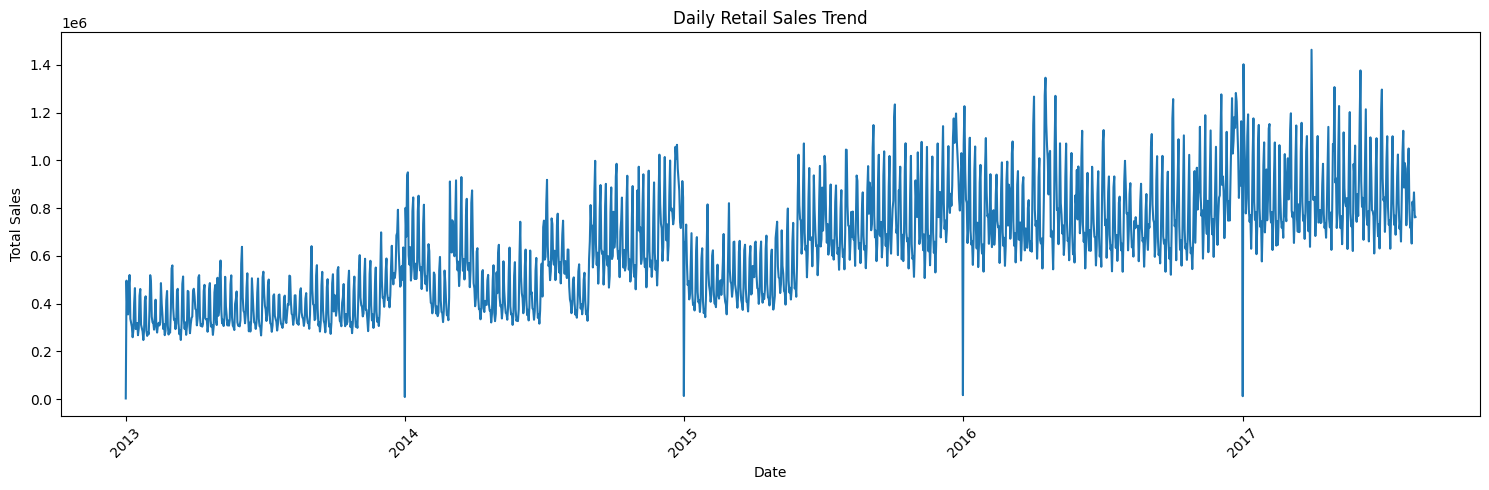

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(daily_sales["date"], daily_sales["sales"])

plt.title("Daily Retail Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
from google.colab import files

files.download("store_sales/train.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files

uploaded = files.upload()

Saving family_daily_sales.csv to family_daily_sales.csv


In [34]:
import pandas as pd

df = pd.read_csv("family_daily_sales.csv")

print(df.shape)
df.head()

(55572, 7)


,date,family,total_sales,total_promotions,total_transactions,oil_price,is_holiday
0,2013-01-01,AUTOMOTIVE,0.0,0,770.0,NaN,1.0
1,2013-01-01,BABY CARE,0.0,0,770.0,NaN,1.0
2,2013-01-01,BEAUTY,2.0,0,770.0,NaN,1.0
3,2013-01-01,BEVERAGES,810.0,0,770.0,NaN,1.0
4,2013-01-01,BOOKS,0.0,0,770.0,NaN,1.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                55572 non-null  object 
 1   family              55572 non-null  object 
 2   total_sales         55572 non-null  float64
 3   total_promotions    55572 non-null  int64  
 4   total_transactions  55506 non-null  float64
 5   oil_price           38379 non-null  float64
 6   is_holiday          8316 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.0+ MB


In [36]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].min())
print(df["date"].max())

2013-01-01 00:00:00
2017-08-15 00:00:00


In [37]:
df = df.sort_values(["family", "date"]).reset_index(drop=True)

df.head()

,date,family,total_sales,total_promotions,total_transactions,oil_price,is_holiday
0,2013-01-01,AUTOMOTIVE,0.0,0,770.0,NaN,1.0
1,2013-01-02,AUTOMOTIVE,255.0,0,93215.0,93.14,NaN
2,2013-01-03,AUTOMOTIVE,161.0,0,78504.0,92.97,NaN
3,2013-01-04,AUTOMOTIVE,169.0,0,78494.0,93.12,NaN
4,2013-01-05,AUTOMOTIVE,342.0,0,93573.0,NaN,1.0


In [38]:
df.isnull().sum()

,0
date,0
family,0
total_sales,0
total_promotions,0
total_transactions,66
oil_price,17193
is_holiday,47256


In [39]:
df["oil_price"] = df.groupby("family")["oil_price"].ffill()

df["oil_price"] = df["oil_price"].bfill()

df["oil_price"].isnull().sum()

np.int64(0)

In [40]:
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

df.head()

,date,family,total_sales,total_promotions,total_transactions,oil_price,is_holiday,day_of_week,day_of_month,week_of_year,month,year
0,2013-01-01,AUTOMOTIVE,0.0,0,770.0,93.14,1.0,1,1,1,1,2013
1,2013-01-02,AUTOMOTIVE,255.0,0,93215.0,93.14,NaN,2,2,1,1,2013
2,2013-01-03,AUTOMOTIVE,161.0,0,78504.0,92.97,NaN,3,3,1,1,2013
3,2013-01-04,AUTOMOTIVE,169.0,0,78494.0,93.12,NaN,4,4,1,1,2013
4,2013-01-05,AUTOMOTIVE,342.0,0,93573.0,93.12,1.0,5,5,1,1,2013


In [41]:
df["lag_1"] = df.groupby("family")["total_sales"].shift(1)
df["lag_7"] = df.groupby("family")["total_sales"].shift(7)
df["lag_14"] = df.groupby("family")["total_sales"].shift(14)
df["lag_28"] = df.groupby("family")["total_sales"].shift(28)

In [42]:
df["rolling_mean_7"] = (
    df.groupby("family")["total_sales"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_mean_14"] = (
    df.groupby("family")["total_sales"]
      .transform(lambda x: x.shift(1).rolling(14).mean())
)

df["rolling_mean_28"] = (
    df.groupby("family")["total_sales"]
      .transform(lambda x: x.shift(1).rolling(28).mean())
)

df.head(40)

,date,family,total_sales,total_promotions,total_transactions,oil_price,is_holiday,day_of_week,day_of_month,week_of_year,month,year,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,2013-01-01,AUTOMOTIVE,0.0,0,770.0,93.14,1.0,1,1,1,1,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,AUTOMOTIVE,255.0,0,93215.0,93.14,NaN,2,2,1,1,2013,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,AUTOMOTIVE,161.0,0,78504.0,92.97,NaN,3,3,1,1,2013,255.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,AUTOMOTIVE,169.0,0,78494.0,93.12,NaN,4,4,1,1,2013,161.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,AUTOMOTIVE,342.0,0,93573.0,93.12,1.0,5,5,1,1,2013,169.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2013-01-06,AUTOMOTIVE,360.0,0,90464.0,93.12,NaN,6,6,1,1,2013,342.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2013-01-07,AUTOMOTIVE,189.0,0,75597.0,93.20,NaN,0,7,2,1,2013,360.0,NaN,NaN,NaN,NaN,NaN,NaN
7,2013-01-08,AUTOMOTIVE,229.0,0,72325.0,93.21,NaN,1,8,2,1,2013,189.0,0.0,NaN,NaN,210.857143,NaN,NaN
8,2013-01-09,AUTOMOTIVE,164.0,0,71971.0,93.08,NaN,2,9,2,1,2013,229.0,255.0,NaN,NaN,243.571429,NaN,NaN
9,2013-01-10,AUTOMOTIVE,164.0,0,66383.0,93.81,NaN,3,10,2,1,2013,164.0,161.0,NaN,NaN,230.571429,NaN,NaN


In [43]:
df_model = df.dropna(
    subset=[
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_28"
    ]
).copy()

print("Shape:", df_model.shape)

Shape: (54648, 19)


In [44]:
print("Start:", df_model["date"].min())
print("End:", df_model["date"].max())

Start: 2013-01-29 00:00:00
End: 2017-08-15 00:00:00


In [45]:
test_start = df_model["date"].max() - pd.Timedelta(days=90)

train_df = df_model[df_model["date"] < test_start].copy()
test_df = df_model[df_model["date"] >= test_start].copy()

print("Training:", train_df.shape)
print("Testing :", test_df.shape)
print("Test start:", test_df["date"].min())

Training: (51645, 19)
Testing : (3003, 19)
Test start: 2017-05-17 00:00:00


In [46]:
X_train = train_df.drop(columns=["total_sales", "date"])
y_train = train_df["total_sales"]

X_test = test_df.drop(columns=["total_sales", "date"])
y_test = test_df["total_sales"]

In [47]:
X_train = pd.get_dummies(X_train, columns=["family"], dtype=int)
X_test = pd.get_dummies(X_test, columns=["family"], dtype=int)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Features:", X_train.shape[1])

Features: 49


In [48]:
baseline_pred = test_df["rolling_mean_7"]

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE : 4458.343683935112
Baseline RMSE: 13077.278462588667


In [54]:
from sklearn.linear_model import LinearRegression

# Fill NaN values in the features before fitting
X_train_clean = X_train.fillna(0)
X_test_clean = X_test.fillna(0)

lr_model = LinearRegression()
lr_model.fit(X_train_clean, y_train)

lr_pred = lr_model.predict(X_test_clean)

In [55]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)

Linear Regression
MAE : 2788.7812705221118
RMSE: 6802.283379936493


In [57]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_clean, y_train)

rf_pred = rf_model.predict(X_test_clean)

In [58]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)

Random Forest
MAE : 1664.9829892357752
RMSE: 5001.275422930702


In [59]:
results = pd.DataFrame({
    "Model": [
        "7-Day Moving Average",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE
2,Random Forest,1664.982989,5001.275423
1,Linear Regression,2788.781271,6802.283380
0,7-Day Moving Average,4458.343684,13077.278463


In [60]:
baseline_wmape = np.sum(np.abs(y_test - baseline_pred)) / np.sum(np.abs(y_test))
lr_wmape = np.sum(np.abs(y_test - lr_pred)) / np.sum(np.abs(y_test))
rf_wmape = np.sum(np.abs(y_test - rf_pred)) / np.sum(np.abs(y_test))

print("Baseline wMAPE :", baseline_wmape * 100, "%")
print("Linear Regression wMAPE :", lr_wmape * 100, "%")
print("Random Forest wMAPE :", rf_wmape * 100, "%")

Baseline wMAPE : 17.201393936966547 %
Linear Regression wMAPE : 10.759808718008896 %
Random Forest wMAPE : 6.423916666494825 %


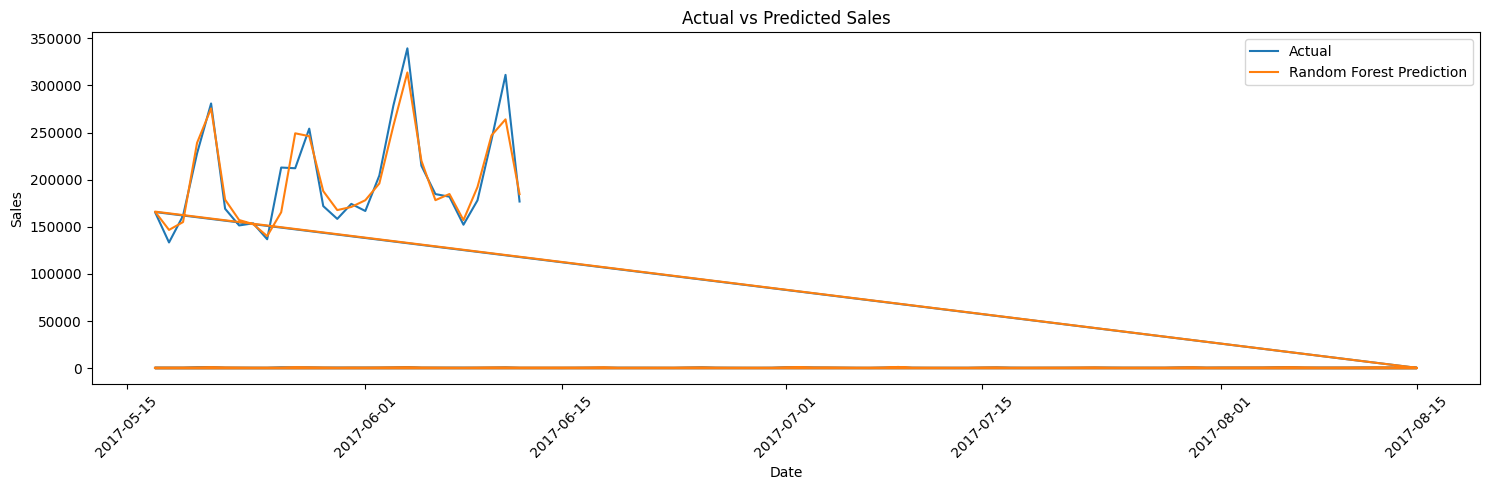

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    test_df["date"].iloc[:300],
    y_test.iloc[:300].values,
    label="Actual"
)

plt.plot(
    test_df["date"].iloc[:300],
    rf_pred[:300],
    label="Random Forest Prediction"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
feature_importance = pd.DataFrame({
    "Feature": X_train_clean.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
13,rolling_mean_7,0.791613
9,lag_1,0.083762
11,lag_14,0.045223
10,lag_7,0.033920
1,total_transactions,0.019914
12,lag_28,0.012516
5,day_of_month,0.002776
15,rolling_mean_28,0.002079
14,rolling_mean_14,0.001653
0,total_promotions,0.001300


In [63]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_clean, y_train)

xgb_pred = xgb_model.predict(X_test_clean)

In [64]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_wmape = (
    np.sum(np.abs(y_test - xgb_pred))
    / np.sum(np.abs(y_test))
)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("wMAPE:", xgb_wmape * 100, "%")

XGBoost
MAE : 1480.5633656501598
RMSE: 4328.998742676475
wMAPE: 5.712380091503082 %


In [65]:
results = pd.DataFrame({
    "Model": [
        "7-Day Moving Average",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "wMAPE (%)": [
        baseline_wmape * 100,
        lr_wmape * 100,
        rf_wmape * 100,
        xgb_wmape * 100
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE,wMAPE (%)
3,XGBoost,1480.563366,4328.998743,5.712380
2,Random Forest,1664.982989,5001.275423,6.423917
1,Linear Regression,2788.781271,6802.283380,10.759809
0,7-Day Moving Average,4458.343684,13077.278463,17.201394


In [66]:
best_model_name = results.loc[results["MAE"].idxmin(), "Model"]

print("Best model based on test MAE:", best_model_name)

Best model based on test MAE: XGBoost


In [67]:
predictions = test_df[
    ["date", "family", "total_sales"]
].copy()

predictions["predicted_sales"] = xgb_pred

predictions.head(10)

,date,family,total_sales,predicted_sales
1593,2017-05-17,AUTOMOTIVE,347.0,312.799561
1594,2017-05-18,AUTOMOTIVE,307.0,306.710358
1595,2017-05-19,AUTOMOTIVE,313.0,310.665649
1596,2017-05-20,AUTOMOTIVE,539.0,425.283173
1597,2017-05-21,AUTOMOTIVE,579.0,475.658417
1598,2017-05-22,AUTOMOTIVE,292.0,326.003937
1599,2017-05-23,AUTOMOTIVE,303.0,264.337036
1600,2017-05-24,AUTOMOTIVE,313.0,345.464294
1601,2017-05-25,AUTOMOTIVE,267.0,287.320496
1602,2017-05-26,AUTOMOTIVE,542.0,349.751129


In [68]:
family_demand = (
    train_df.groupby("family")["total_sales"]
    .agg(["mean", "std"])
    .reset_index()
)

family_demand.columns = [
    "family",
    "avg_daily_demand",
    "demand_std"
]

family_demand.head()

,family,avg_daily_demand,demand_std
0,AUTOMOTIVE,327.747604,107.516279
1,BABY CARE,5.830671,8.065355
2,BEAUTY,194.943770,95.936990
3,BEVERAGES,126411.453035,61802.109674
4,BOOKS,4.010224,13.426408


In [69]:
lead_time_days = 7
z_score = 1.65
forecast_horizon = 7

In [70]:
family_demand["safety_stock"] = (
    z_score
    * family_demand["demand_std"]
    * np.sqrt(lead_time_days)
)

family_demand.head()

,family,avg_daily_demand,demand_std,safety_stock
0,AUTOMOTIVE,327.747604,107.516279,469.361203
1,BABY CARE,5.830671,8.065355,35.209225
2,BEAUTY,194.943770,95.936990,418.811938
3,BEVERAGES,126411.453035,61802.109674,269796.470949
4,BOOKS,4.010224,13.426408,58.612846


In [71]:
family_demand["reorder_point"] = (
    family_demand["avg_daily_demand"] * lead_time_days
    + family_demand["safety_stock"]
)

family_demand.head()

,family,avg_daily_demand,demand_std,safety_stock,reorder_point
0,AUTOMOTIVE,327.747604,107.516279,469.361203,2.763594e+03
1,BABY CARE,5.830671,8.065355,35.209225,7.602392e+01
2,BEAUTY,194.943770,95.936990,418.811938,1.783418e+03
3,BEVERAGES,126411.453035,61802.109674,269796.470949,1.154677e+06
4,BOOKS,4.010224,13.426408,58.612846,8.668441e+01


In [72]:
predictions = predictions.sort_values(["family", "date"])

predictions["forecast_7_day"] = (
    predictions.groupby("family")["predicted_sales"]
    .transform(lambda x: x.rolling(7, min_periods=1).sum())
)

predictions.head(10)

,date,family,total_sales,predicted_sales,forecast_7_day
1593,2017-05-17,AUTOMOTIVE,347.0,312.799561,312.799561
1594,2017-05-18,AUTOMOTIVE,307.0,306.710358,619.509918
1595,2017-05-19,AUTOMOTIVE,313.0,310.665649,930.175568
1596,2017-05-20,AUTOMOTIVE,539.0,425.283173,1355.458740
1597,2017-05-21,AUTOMOTIVE,579.0,475.658417,1831.117157
1598,2017-05-22,AUTOMOTIVE,292.0,326.003937,2157.121094
1599,2017-05-23,AUTOMOTIVE,303.0,264.337036,2421.458130
1600,2017-05-24,AUTOMOTIVE,313.0,345.464294,2454.122864
1601,2017-05-25,AUTOMOTIVE,267.0,287.320496,2434.733002
1602,2017-05-26,AUTOMOTIVE,542.0,349.751129,2473.818481


In [73]:
inventory_plan = predictions.merge(
    family_demand,
    on="family",
    how="left"
)

inventory_plan[
    [
        "date",
        "family",
        "predicted_sales",
        "forecast_7_day",
        "safety_stock",
        "reorder_point"
    ]
].head(10)

,date,family,predicted_sales,forecast_7_day,safety_stock,reorder_point
0,2017-05-17,AUTOMOTIVE,312.799561,312.799561,469.361203,2763.59443
1,2017-05-18,AUTOMOTIVE,306.710358,619.509918,469.361203,2763.59443
2,2017-05-19,AUTOMOTIVE,310.665649,930.175568,469.361203,2763.59443
3,2017-05-20,AUTOMOTIVE,425.283173,1355.458740,469.361203,2763.59443
4,2017-05-21,AUTOMOTIVE,475.658417,1831.117157,469.361203,2763.59443
5,2017-05-22,AUTOMOTIVE,326.003937,2157.121094,469.361203,2763.59443
6,2017-05-23,AUTOMOTIVE,264.337036,2421.458130,469.361203,2763.59443
7,2017-05-24,AUTOMOTIVE,345.464294,2454.122864,469.361203,2763.59443
8,2017-05-25,AUTOMOTIVE,287.320496,2434.733002,469.361203,2763.59443
9,2017-05-26,AUTOMOTIVE,349.751129,2473.818481,469.361203,2763.59443


In [74]:
inventory_plan["recommended_stock"] = (
    inventory_plan["forecast_7_day"]
    + inventory_plan["safety_stock"]
)

inventory_plan[
    ["date", "family", "forecast_7_day", "safety_stock", "recommended_stock"]
].head(10)

,date,family,forecast_7_day,safety_stock,recommended_stock
0,2017-05-17,AUTOMOTIVE,312.799561,469.361203,782.160764
1,2017-05-18,AUTOMOTIVE,619.509918,469.361203,1088.871122
2,2017-05-19,AUTOMOTIVE,930.175568,469.361203,1399.536771
3,2017-05-20,AUTOMOTIVE,1355.458740,469.361203,1824.819944
4,2017-05-21,AUTOMOTIVE,1831.117157,469.361203,2300.478360
5,2017-05-22,AUTOMOTIVE,2157.121094,469.361203,2626.482297
6,2017-05-23,AUTOMOTIVE,2421.458130,469.361203,2890.819333
7,2017-05-24,AUTOMOTIVE,2454.122864,469.361203,2923.484067
8,2017-05-25,AUTOMOTIVE,2434.733002,469.361203,2904.094205
9,2017-05-26,AUTOMOTIVE,2473.818481,469.361203,2943.179685


In [75]:
high_demand = (
    inventory_plan.groupby("family")["predicted_sales"]
    .mean()
    .reset_index(name="avg_predicted_daily_sales")
    .sort_values("avg_predicted_daily_sales", ascending=False)
)

high_demand.head(10)

,family,avg_predicted_daily_sales
12,GROCERY I,259551.625000
3,BEVERAGES,195679.390625
30,PRODUCE,131547.125000
7,CLEANING,70673.976562
8,DAIRY,50944.957031
5,BREAD/BAKERY,30479.001953
28,POULTRY,21724.417969
24,MEATS,20755.705078
9,DELI,17620.560547
25,PERSONAL CARE,17444.021484


In [76]:
inventory_plan["demand_ratio"] = (
    inventory_plan["forecast_7_day"]
    / (inventory_plan["avg_daily_demand"] * forecast_horizon)
)

inventory_plan["risk"] = np.select(
    [
        inventory_plan["demand_ratio"] >= 1.20,
        inventory_plan["demand_ratio"] <= 0.80
    ],
    [
        "High Demand Risk",
        "Low Demand"
    ],
    default="Normal"
)

inventory_plan[
    ["date", "family", "forecast_7_day", "demand_ratio", "risk"]
].head(20)

,date,family,forecast_7_day,demand_ratio,risk
0,2017-05-17,AUTOMOTIVE,312.799561,0.136342,Low Demand
1,2017-05-18,AUTOMOTIVE,619.509918,0.270029,Low Demand
2,2017-05-19,AUTOMOTIVE,930.175568,0.405441,Low Demand
3,2017-05-20,AUTOMOTIVE,1355.458740,0.590811,Low Demand
4,2017-05-21,AUTOMOTIVE,1831.117157,0.798139,Low Demand
5,2017-05-22,AUTOMOTIVE,2157.121094,0.940236,Normal
6,2017-05-23,AUTOMOTIVE,2421.458130,1.055454,Normal
7,2017-05-24,AUTOMOTIVE,2454.122864,1.069692,Normal
8,2017-05-25,AUTOMOTIVE,2434.733002,1.061240,Normal
9,2017-05-26,AUTOMOTIVE,2473.818481,1.078277,Normal


In [77]:
final_inventory = (
    inventory_plan[
        [
            "date",
            "family",
            "predicted_sales",
            "forecast_7_day",
            "avg_daily_demand",
            "safety_stock",
            "reorder_point",
            "recommended_stock",
            "risk"
        ]
    ]
    .sort_values(["date", "recommended_stock"], ascending=[False, False])
)

final_inventory.head(20)

,date,family,predicted_sales,forecast_7_day,avg_daily_demand,safety_stock,reorder_point,recommended_stock,risk
1182,2017-08-15,GROCERY I,242801.250000,1.690123e+06,202416.925355,265774.553427,1.682693e+06,1.955898e+06,Normal
363,2017-08-15,BEVERAGES,181732.703125,1.303961e+06,126411.453035,269796.470949,1.154677e+06,1.573758e+06,High Demand Risk
2820,2017-08-15,PRODUCE,131119.703125,8.640189e+05,70909.577169,269278.240034,7.656453e+05,1.133297e+06,High Demand Risk
727,2017-08-15,CLEANING,61384.824219,4.228871e+05,57406.357188,64770.260893,4.666148e+05,4.876574e+05,Normal
818,2017-08-15,DAIRY,44684.855469,3.175944e+05,38062.509904,58839.024130,3.252766e+05,3.764335e+05,Normal
545,2017-08-15,BREAD/BAKERY,27856.673828,1.999937e+05,24863.210390,28024.024043,2.020665e+05,2.280177e+05,Normal
2638,2017-08-15,POULTRY,17851.607422,1.393920e+05,18946.213195,26268.279943,1.588918e+05,1.656603e+05,Normal
2274,2017-08-15,MEATS,17032.398438,1.385429e+05,18359.167080,18796.455143,1.473106e+05,1.573393e+05,Normal
1728,2017-08-15,HOME CARE,14889.594727,1.058079e+05,9282.081150,35611.093216,1.005857e+05,1.414190e+05,High Demand Risk
2365,2017-08-15,PERSONAL CARE,15393.666992,1.104050e+05,14530.969329,23358.229205,1.250750e+05,1.337632e+05,Normal


In [78]:
drop_cols = ["total_sales", "date", "total_transactions"]

X_train_final = train_df.drop(columns=drop_cols)
X_test_final = test_df.drop(columns=drop_cols)

y_train = train_df["total_sales"]
y_test = test_df["total_sales"]

In [79]:
X_train_final = pd.get_dummies(
    X_train_final,
    columns=["family"],
    dtype=int
)

X_test_final = pd.get_dummies(
    X_test_final,
    columns=["family"],
    dtype=int
)

X_train_final, X_test_final = X_train_final.align(
    X_test_final,
    join="left",
    axis=1,
    fill_value=0
)

In [80]:
X_train_final = X_train_final.fillna(0)
X_test_final = X_test_final.fillna(0)

print(X_train_final.shape)
print(X_test_final.shape)

(51645, 48)
(3003, 48)


In [81]:
from xgboost import XGBRegressor

final_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_final, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [82]:
final_pred = final_model.predict(X_test_final)

In [83]:
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

final_wmape = (
    np.sum(np.abs(y_test - final_pred))
    / np.sum(np.abs(y_test))
)

print("Final XGBoost Model")
print("MAE   :", final_mae)
print("RMSE  :", final_rmse)
print("wMAPE :", final_wmape * 100, "%")

Final XGBoost Model
MAE   : 1545.2099937436726
RMSE  : 4768.749343482923
wMAPE : 5.961802790910494 %


In [84]:
final_predictions = test_df[
    ["date", "family", "total_sales"]
].copy()

final_predictions["predicted_sales"] = final_pred

final_predictions.head(10)

,date,family,total_sales,predicted_sales
1593,2017-05-17,AUTOMOTIVE,347.0,316.974915
1594,2017-05-18,AUTOMOTIVE,307.0,319.926147
1595,2017-05-19,AUTOMOTIVE,313.0,315.489319
1596,2017-05-20,AUTOMOTIVE,539.0,404.978943
1597,2017-05-21,AUTOMOTIVE,579.0,424.028137
1598,2017-05-22,AUTOMOTIVE,292.0,318.853302
1599,2017-05-23,AUTOMOTIVE,303.0,249.096512
1600,2017-05-24,AUTOMOTIVE,313.0,324.731506
1601,2017-05-25,AUTOMOTIVE,267.0,295.657104
1602,2017-05-26,AUTOMOTIVE,542.0,289.118347


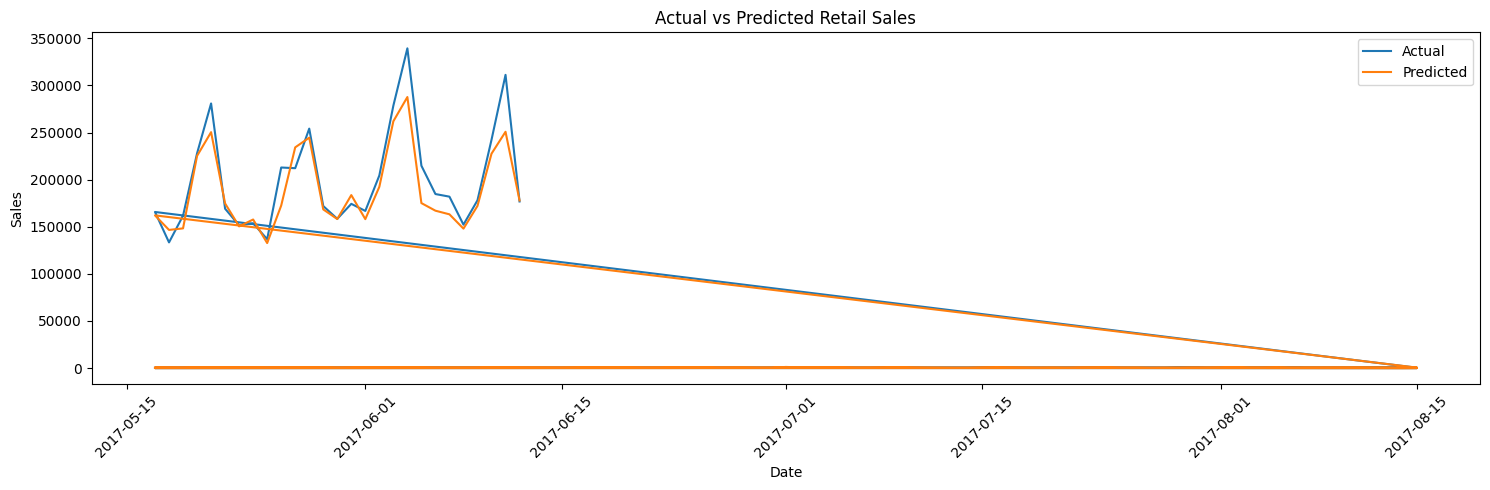

In [85]:
import matplotlib.pyplot as plt

plot_data = final_predictions.head(300)

plt.figure(figsize=(15, 5))

plt.plot(
    plot_data["date"],
    plot_data["total_sales"],
    label="Actual"
)

plt.plot(
    plot_data["date"],
    plot_data["predicted_sales"],
    label="Predicted"
)

plt.title("Actual vs Predicted Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
12,rolling_mean_7,0.670907
13,rolling_mean_14,0.124741
8,lag_1,0.083387
9,lag_7,0.037191
10,lag_14,0.027227
11,lag_28,0.012603
45,family_PRODUCE,0.008373
3,day_of_week,0.004789
27,family_GROCERY I,0.003803
2,is_holiday,0.003453


In [87]:
import joblib

joblib.dump(
    final_model,
    "retail_demand_forecasting_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [88]:
feature_columns = X_train_final.columns.tolist()

joblib.dump(
    feature_columns,
    "retail_forecasting_features.pkl"
)

print("Feature columns saved:", len(feature_columns))

Feature columns saved: 48


In [89]:
history_data = df[
    [
        "date",
        "family",
        "total_sales",
        "total_promotions",
        "oil_price",
        "is_holiday"
    ]
].copy()

history_data.to_csv(
    "retail_forecasting_history.csv",
    index=False
)

print(history_data.shape)

(55572, 6)


In [90]:
final_predictions.to_csv(
    "retail_forecasting_predictions.csv",
    index=False
)

print("Prediction file saved.")

Prediction file saved.


In [91]:
import os

files_to_check = [
    "retail_demand_forecasting_model.pkl",
    "retail_forecasting_features.pkl",
    "retail_forecasting_history.csv",
    "retail_forecasting_predictions.csv"
]

for file in files_to_check:
    print(file, "->", os.path.getsize(file) / (1024 * 1024), "MB")

retail_demand_forecasting_model.pkl -> 5.511954307556152 MB
retail_forecasting_features.pkl -> 0.0008497238159179688 MB
retail_forecasting_history.csv -> 2.0959320068359375 MB
retail_forecasting_predictions.csv -> 0.11347103118896484 MB


In [92]:
loaded_model = joblib.load(
    "retail_demand_forecasting_model.pkl"
)

print(type(loaded_model))

<class 'xgboost.sklearn.XGBRegressor'>


In [93]:
loaded_features = joblib.load(
    "retail_forecasting_features.pkl"
)

print("Number of features:", len(loaded_features))
print(loaded_features[:10])

Number of features: 48
['total_promotions', 'oil_price', 'is_holiday', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'year', 'lag_1', 'lag_7']


In [94]:
history = pd.read_csv(
    "retail_forecasting_history.csv"
)

history["date"] = pd.to_datetime(history["date"])

history = history.sort_values(
    ["family", "date"]
).reset_index(drop=True)

history.head()

,date,family,total_sales,total_promotions,oil_price,is_holiday
0,2013-01-01,AUTOMOTIVE,0.0,0,93.14,1.0
1,2013-01-02,AUTOMOTIVE,255.0,0,93.14,NaN
2,2013-01-03,AUTOMOTIVE,161.0,0,92.97,NaN
3,2013-01-04,AUTOMOTIVE,169.0,0,93.12,NaN
4,2013-01-05,AUTOMOTIVE,342.0,0,93.12,1.0


In [95]:
families = sorted(
    history["family"].unique()
)

print("Number of families:", len(families))
print(families)

Number of families: 33
['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


In [96]:
def prepare_family_history(family_name):
    family_history = history[
        history["family"] == family_name
    ].copy()

    family_history = family_history.sort_values("date")

    return family_history.reset_index(drop=True)

In [97]:
sample_history = prepare_family_history("GROCERY I")

sample_history.tail()

,date,family,total_sales,total_promotions,oil_price,is_holiday
1679,2017-08-11,GROCERY I,238221.91,2349,48.81,1.0
1680,2017-08-12,GROCERY I,238627.64,2325,48.81,NaN
1681,2017-08-13,GROCERY I,258442.45,2320,48.81,NaN
1682,2017-08-14,GROCERY I,225355.71,2335,47.59,NaN
1683,2017-08-15,GROCERY I,224208.11,2296,47.57,1.0


In [98]:
print(
    "Latest available date:",
    history["date"].max()
)

print(
    "Latest GROCERY I date:",
    sample_history["date"].max()
)

Latest available date: 2017-08-15 00:00:00
Latest GROCERY I date: 2017-08-15 00:00:00


In [99]:
test_raw = pd.read_csv(
    "store_sales/test.csv"
)

test_raw["date"] = pd.to_datetime(test_raw["date"])

print(test_raw.shape)
test_raw.head()

(28512, 5)


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


In [100]:
future_promotions = (
    test_raw.groupby(["date", "family"])["onpromotion"]
    .sum()
    .reset_index(name="total_promotions")
)

future_promotions.head()

,date,family,total_promotions
0,2017-08-16,AUTOMOTIVE,0
1,2017-08-16,BABY CARE,0
2,2017-08-16,BEAUTY,108
3,2017-08-16,BEVERAGES,1706
4,2017-08-16,BOOKS,0


In [101]:
future_df = future_promotions.copy()

future_df["day_of_week"] = future_df["date"].dt.dayofweek
future_df["day_of_month"] = future_df["date"].dt.day
future_df["week_of_year"] = (
    future_df["date"].dt.isocalendar().week.astype(int)
)
future_df["month"] = future_df["date"].dt.month
future_df["year"] = future_df["date"].dt.year

future_df.head()

,date,family,total_promotions,day_of_week,day_of_month,week_of_year,month,year
0,2017-08-16,AUTOMOTIVE,0,2,16,33,8,2017
1,2017-08-16,BABY CARE,0,2,16,33,8,2017
2,2017-08-16,BEAUTY,108,2,16,33,8,2017
3,2017-08-16,BEVERAGES,1706,2,16,33,8,2017
4,2017-08-16,BOOKS,0,2,16,33,8,2017


In [102]:
oil_future = oil.copy()

oil_future["date"] = pd.to_datetime(oil_future["date"])

oil_future["dcoilwtico"] = (
    oil_future["dcoilwtico"].ffill().bfill()
)

future_df = future_df.merge(
    oil_future,
    on="date",
    how="left"
)

future_df = future_df.rename(
    columns={"dcoilwtico": "oil_price"}
)

future_df["oil_price"] = (
    future_df["oil_price"].ffill().bfill()
)

future_df.head()

,date,family,total_promotions,day_of_week,day_of_month,week_of_year,month,year,oil_price
0,2017-08-16,AUTOMOTIVE,0,2,16,33,8,2017,46.8
1,2017-08-16,BABY CARE,0,2,16,33,8,2017,46.8
2,2017-08-16,BEAUTY,108,2,16,33,8,2017,46.8
3,2017-08-16,BEVERAGES,1706,2,16,33,8,2017,46.8
4,2017-08-16,BOOKS,0,2,16,33,8,2017,46.8


In [106]:
# Load holidays data into Colab
holidays = pd.read_csv(
    "store_sales/holidays_events.csv"
)

# Convert date column
holidays["date"] = pd.to_datetime(holidays["date"])

# Create a date-level holiday flag
holiday_flags = (
    holidays[["date"]]
    .drop_duplicates()
    .copy()
)

holiday_flags["is_holiday"] = 1

holiday_flags.head()

,date,is_holiday
0,2012-03-02,1
1,2012-04-01,1
2,2012-04-12,1
3,2012-04-14,1
4,2012-04-21,1


In [103]:
forecast_history = history[
    [
        "date",
        "family",
        "total_sales"
    ]
].copy()

forecast_history["date"] = pd.to_datetime(
    forecast_history["date"]
)

forecast_history = forecast_history.sort_values(
    ["family", "date"]
).reset_index(drop=True)

forecast_history.tail()

,date,family,total_sales
55567,2017-08-11,SEAFOOD,1272.60
55568,2017-08-12,SEAFOOD,1028.02
55569,2017-08-13,SEAFOOD,1118.08
55570,2017-08-14,SEAFOOD,970.66
55571,2017-08-15,SEAFOOD,970.18


In [107]:
future_df = future_df.merge(
    holiday_flags,
    on="date",
    how="left"
)

future_df["is_holiday"] = (
    future_df["is_holiday"]
    .fillna(0)
    .astype(int)
)

future_df.head()

,date,family,total_promotions,day_of_week,day_of_month,week_of_year,month,year,oil_price,is_holiday
0,2017-08-16,AUTOMOTIVE,0,2,16,33,8,2017,46.8,0
1,2017-08-16,BABY CARE,0,2,16,33,8,2017,46.8,0
2,2017-08-16,BEAUTY,108,2,16,33,8,2017,46.8,0
3,2017-08-16,BEVERAGES,1706,2,16,33,8,2017,46.8,0
4,2017-08-16,BOOKS,0,2,16,33,8,2017,46.8,0


In [108]:
forecast_history = history[
    [
        "date",
        "family",
        "total_sales"
    ]
].copy()

forecast_history["date"] = pd.to_datetime(
    forecast_history["date"]
)

forecast_history = forecast_history.sort_values(
    ["family", "date"]
).reset_index(drop=True)

forecast_history.tail()

,date,family,total_sales
55567,2017-08-11,SEAFOOD,1272.60
55568,2017-08-12,SEAFOOD,1028.02
55569,2017-08-13,SEAFOOD,1118.08
55570,2017-08-14,SEAFOOD,970.66
55571,2017-08-15,SEAFOOD,970.18


In [109]:
def forecast_family(
    family_name,
    future_dates,
    model,
    historical_data,
    feature_columns
):
    family_history = historical_data[
        historical_data["family"] == family_name
    ].copy()

    family_history = family_history.sort_values("date").reset_index(drop=True)

    outputs = []

    for _, future_row in future_dates.iterrows():

        date = future_row["date"]

        sales_values = family_history["total_sales"].tolist()

        lag_1 = sales_values[-1]
        lag_7 = sales_values[-7]
        lag_14 = sales_values[-14]
        lag_28 = sales_values[-28]

        rolling_mean_7 = np.mean(sales_values[-7:])
        rolling_mean_14 = np.mean(sales_values[-14:])
        rolling_mean_28 = np.mean(sales_values[-28:])

        row = {
            "family": family_name,
            "total_promotions": future_row["total_promotions"],
            "oil_price": future_row["oil_price"],
            "is_holiday": future_row["is_holiday"],
            "day_of_week": date.dayofweek,
            "day_of_month": date.day,
            "week_of_year": int(date.isocalendar().week),
            "month": date.month,
            "year": date.year,
            "lag_1": lag_1,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "lag_28": lag_28,
            "rolling_mean_7": rolling_mean_7,
            "rolling_mean_14": rolling_mean_14,
            "rolling_mean_28": rolling_mean_28
        }

        row_df = pd.DataFrame([row])

        row_df = pd.get_dummies(
            row_df,
            columns=["family"],
            dtype=int
        )

        row_df = row_df.reindex(
            columns=feature_columns,
            fill_value=0
        )

        row_df = row_df.fillna(0)

        prediction = model.predict(row_df)[0]
        prediction = max(0, prediction)

        outputs.append({
            "date": date,
            "family": family_name,
            "predicted_sales": prediction
        })

        family_history.loc[len(family_history)] = [
            date,
            family_name,
            prediction
        ]

    return pd.DataFrame(outputs)

In [110]:
grocery_future = future_df[
    future_df["family"] == "GROCERY I"
].sort_values("date").copy()

grocery_forecast = forecast_family(
    "GROCERY I",
    grocery_future,
    loaded_model,
    forecast_history,
    loaded_features
)

grocery_forecast.head(10)

,date,family,predicted_sales
0,2017-08-16,GROCERY I,223739.125000
1,2017-08-17,GROCERY I,199619.656250
2,2017-08-18,GROCERY I,219577.328125
3,2017-08-19,GROCERY I,278104.468750
4,2017-08-20,GROCERY I,314351.000000
5,2017-08-21,GROCERY I,228925.343750
6,2017-08-22,GROCERY I,214330.218750
7,2017-08-23,GROCERY I,208773.468750
8,2017-08-24,GROCERY I,208071.406250
9,2017-08-25,GROCERY I,225493.156250


In [111]:
print("Forecast rows:", len(grocery_forecast))
print("Forecast start:", grocery_forecast["date"].min())
print("Forecast end:", grocery_forecast["date"].max())

Forecast rows: 16
Forecast start: 2017-08-16 00:00:00
Forecast end: 2017-08-31 00:00:00


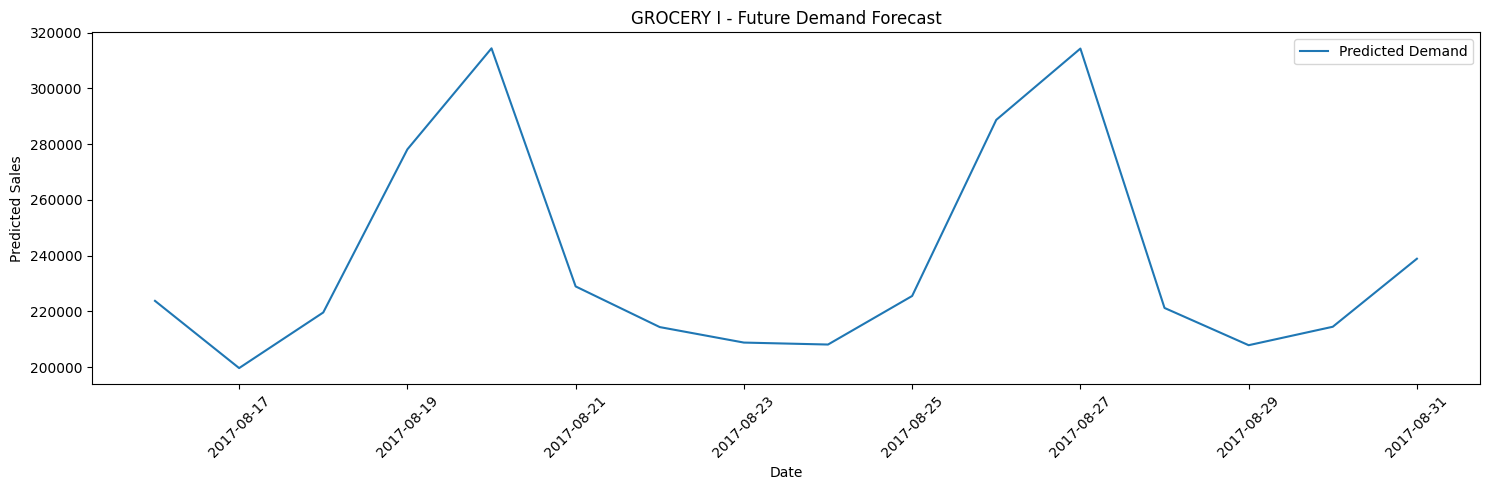

In [112]:
plt.figure(figsize=(15, 5))

plt.plot(
    grocery_forecast["date"],
    grocery_forecast["predicted_sales"],
    label="Predicted Demand"
)

plt.title("GROCERY I - Future Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [113]:
all_forecasts = []

families = sorted(future_df["family"].unique())

for family in families:
    family_future = (
        future_df[future_df["family"] == family]
        .sort_values("date")
        .copy()
    )

    family_forecast = forecast_family(
        family,
        family_future,
        loaded_model,
        forecast_history,
        loaded_features
    )

    all_forecasts.append(family_forecast)

all_forecasts = pd.concat(
    all_forecasts,
    ignore_index=True
)

print("Total forecast rows:", len(all_forecasts))
all_forecasts.head(20)

Total forecast rows: 528


,date,family,predicted_sales
0,2017-08-16,AUTOMOTIVE,260.643127
1,2017-08-17,AUTOMOTIVE,175.376495
2,2017-08-18,AUTOMOTIVE,195.032700
3,2017-08-19,AUTOMOTIVE,198.078262
4,2017-08-20,AUTOMOTIVE,183.435959
5,2017-08-21,AUTOMOTIVE,89.145111
6,2017-08-22,AUTOMOTIVE,8.911324
7,2017-08-23,AUTOMOTIVE,0.000000
8,2017-08-24,AUTOMOTIVE,0.000000
9,2017-08-25,AUTOMOTIVE,0.000000


In [114]:
print(
    "Number of families:",
    all_forecasts["family"].nunique()
)

print(
    sorted(all_forecasts["family"].unique())
)

Number of families: 33
['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


In [115]:
print(
    "Forecast start:",
    all_forecasts["date"].min()
)

print(
    "Forecast end:",
    all_forecasts["date"].max()
)

Forecast start: 2017-08-16 00:00:00
Forecast end: 2017-08-31 00:00:00


In [116]:
family_forecast_summary = (
    all_forecasts
    .groupby("family")["predicted_sales"]
    .sum()
    .reset_index(name="forecasted_demand")
    .sort_values(
        "forecasted_demand",
        ascending=False
    )
)

family_forecast_summary.head(10)

,family,forecasted_demand
12,GROCERY I,3.806264e+06
3,BEVERAGES,2.854610e+06
30,PRODUCE,1.893699e+06
7,CLEANING,9.320979e+05
8,DAIRY,6.901284e+05
20,LAWN AND GARDEN,6.849294e+05
5,BREAD/BAKERY,4.475971e+05
31,SCHOOL AND OFFICE SUPPLIES,3.621396e+05
24,MEATS,3.032328e+05
28,POULTRY,3.013105e+05


In [117]:
all_forecasts["forecast_week"] = (
    all_forecasts["date"]
    .dt.to_period("W")
    .astype(str)
)

weekly_forecast = (
    all_forecasts
    .groupby(["forecast_week", "family"])["predicted_sales"]
    .sum()
    .reset_index(name="predicted_weekly_demand")
)

weekly_forecast.head(20)

,forecast_week,family,predicted_weekly_demand
0,2017-08-14/2017-08-20,AUTOMOTIVE,1.012567e+03
1,2017-08-14/2017-08-20,BABY CARE,0.000000e+00
2,2017-08-14/2017-08-20,BEAUTY,2.416323e+03
3,2017-08-14/2017-08-20,BEVERAGES,9.554017e+05
4,2017-08-14/2017-08-20,BOOKS,0.000000e+00
5,2017-08-14/2017-08-20,BREAD/BAKERY,1.452486e+05
6,2017-08-14/2017-08-20,CELEBRATION,2.797235e+03
7,2017-08-14/2017-08-20,CLEANING,3.030467e+05
8,2017-08-14/2017-08-20,DAIRY,2.294397e+05
9,2017-08-14/2017-08-20,DELI,8.649770e+04


In [118]:
family_stats = (
    history.groupby("family")["total_sales"]
    .agg(
        avg_daily_demand="mean",
        demand_std="std"
    )
    .reset_index()
)

family_stats.head()

,family,avg_daily_demand,demand_std
0,AUTOMOTIVE,329.466746,108.627015
1,BABY CARE,5.968527,7.947142
2,BEAUTY,200.649050,100.410387
3,BEVERAGES,128832.830166,63121.645563
4,BOOKS,3.823040,12.968935


In [119]:
lead_time_days = 7
z_score = 1.65

family_stats["safety_stock"] = (
    z_score
    * family_stats["demand_std"]
    * np.sqrt(lead_time_days)
)

family_stats.head()

,family,avg_daily_demand,demand_std,safety_stock
0,AUTOMOTIVE,329.466746,108.627015,474.210111
1,BABY CARE,5.968527,7.947142,34.693165
2,BEAUTY,200.649050,100.410387,438.340505
3,BEVERAGES,128832.830166,63121.645563,275556.891233
4,BOOKS,3.823040,12.968935,56.615750


In [120]:
forecast_start = all_forecasts["date"].min()
forecast_end = forecast_start + pd.Timedelta(days=6)

next_7_days = all_forecasts[
    (all_forecasts["date"] >= forecast_start) &
    (all_forecasts["date"] <= forecast_end)
].copy()

weekly_demand = (
    next_7_days
    .groupby("family")["predicted_sales"]
    .sum()
    .reset_index(name="predicted_7_day_demand")
)

weekly_demand.head()

,family,predicted_7_day_demand
0,AUTOMOTIVE,1.110623e+03
1,BABY CARE,0.000000e+00
2,BEAUTY,3.258067e+03
3,BEVERAGES,1.281553e+06
4,BOOKS,0.000000e+00


In [121]:
inventory_recommendation = weekly_demand.merge(
    family_stats,
    on="family",
    how="left"
)

inventory_recommendation["recommended_stock"] = (
    inventory_recommendation["predicted_7_day_demand"]
    + inventory_recommendation["safety_stock"]
)

inventory_recommendation = inventory_recommendation.sort_values(
    "recommended_stock",
    ascending=False
)

inventory_recommendation.head(15)

,family,predicted_7_day_demand,avg_daily_demand,demand_std,safety_stock,recommended_stock
12,GROCERY I,1.678647e+06,203956.497340,61832.886542,269930.827049,1.948578e+06
3,BEVERAGES,1.281553e+06,128832.830166,63121.645563,275556.891233,1.557110e+06
30,PRODUCE,8.490980e+05,72865.030327,61847.264941,269993.595802,1.119092e+06
7,CLEANING,4.133401e+05,57910.504157,15211.880756,66407.308200,4.797474e+05
8,DAIRY,3.110066e+05,38294.364014,13725.805476,59919.861926,3.709264e+05
20,LAWN AND GARDEN,3.240714e+05,325.915677,340.509496,1486.490683,3.255578e+05
5,BREAD/BAKERY,1.997710e+05,25020.169537,6511.796257,28427.179250,2.281982e+05
31,SCHOOL AND OFFICE SUPPLIES,1.873433e+05,159.926366,429.102006,1873.240372,1.892165e+05
28,POULTRY,1.365929e+05,18928.766496,6078.422400,26535.290155,1.631282e+05
24,MEATS,1.359288e+05,18459.920879,4334.043639,18920.222706,1.548490e+05


In [122]:
inventory_recommendation["demand_vs_history"] = (
    inventory_recommendation["predicted_7_day_demand"]
    /
    (
        inventory_recommendation["avg_daily_demand"]
        * 7
    )
)

inventory_recommendation["risk_category"] = np.select(
    [
        inventory_recommendation["demand_vs_history"] >= 1.20,
        inventory_recommendation["demand_vs_history"] <= 0.80
    ],
    [
        "High Demand",
        "Low Demand"
    ],
    default="Normal"
)

inventory_recommendation.head(15)

,family,predicted_7_day_demand,avg_daily_demand,demand_std,safety_stock,recommended_stock,demand_vs_history,risk_category
12,GROCERY I,1.678647e+06,203956.497340,61832.886542,269930.827049,1.948578e+06,1.175774,Normal
3,BEVERAGES,1.281553e+06,128832.830166,63121.645563,275556.891233,1.557110e+06,1.421059,High Demand
30,PRODUCE,8.490980e+05,72865.030327,61847.264941,269993.595802,1.119092e+06,1.664718,High Demand
7,CLEANING,4.133401e+05,57910.504157,15211.880756,66407.308200,4.797474e+05,1.019652,Normal
8,DAIRY,3.110066e+05,38294.364014,13725.805476,59919.861926,3.709264e+05,1.160210,Normal
20,LAWN AND GARDEN,3.240714e+05,325.915677,340.509496,1486.490683,3.255578e+05,142.048728,High Demand
5,BREAD/BAKERY,1.997710e+05,25020.169537,6511.796257,28427.179250,2.281982e+05,1.140628,Normal
31,SCHOOL AND OFFICE SUPPLIES,1.873433e+05,159.926366,429.102006,1873.240372,1.892165e+05,167.347779,High Demand
28,POULTRY,1.365929e+05,18928.766496,6078.422400,26535.290155,1.631282e+05,1.030879,Normal
24,MEATS,1.359288e+05,18459.920879,4334.043639,18920.222706,1.548490e+05,1.051922,Normal


In [123]:
total_forecast_demand = all_forecasts["predicted_sales"].sum()

print("Total predicted demand:", round(total_forecast_demand, 2))

Total predicted demand: 13551049.05


In [124]:
top_10_families = (
    family_forecast_summary
    .head(10)
)

top_10_families

,family,forecasted_demand
12,GROCERY I,3.806264e+06
3,BEVERAGES,2.854610e+06
30,PRODUCE,1.893699e+06
7,CLEANING,9.320979e+05
8,DAIRY,6.901284e+05
20,LAWN AND GARDEN,6.849294e+05
5,BREAD/BAKERY,4.475971e+05
31,SCHOOL AND OFFICE SUPPLIES,3.621396e+05
24,MEATS,3.032328e+05
28,POULTRY,3.013105e+05


In [125]:
risk_summary = (
    inventory_recommendation["risk_category"]
    .value_counts()
    .reset_index()
)

risk_summary.columns = [
    "risk_category",
    "family_count"
]

risk_summary

,risk_category,family_count
0,Normal,13
1,High Demand,13
2,Low Demand,7


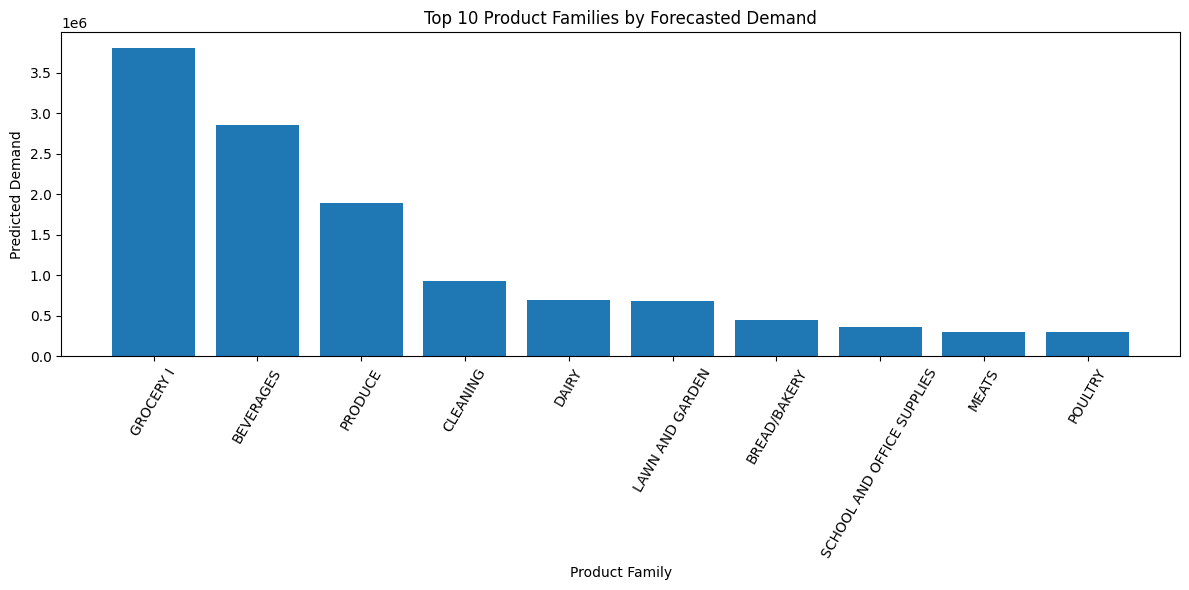

In [126]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_families["family"],
    top_10_families["forecasted_demand"]
)

plt.title("Top 10 Product Families by Forecasted Demand")
plt.xlabel("Product Family")
plt.ylabel("Predicted Demand")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

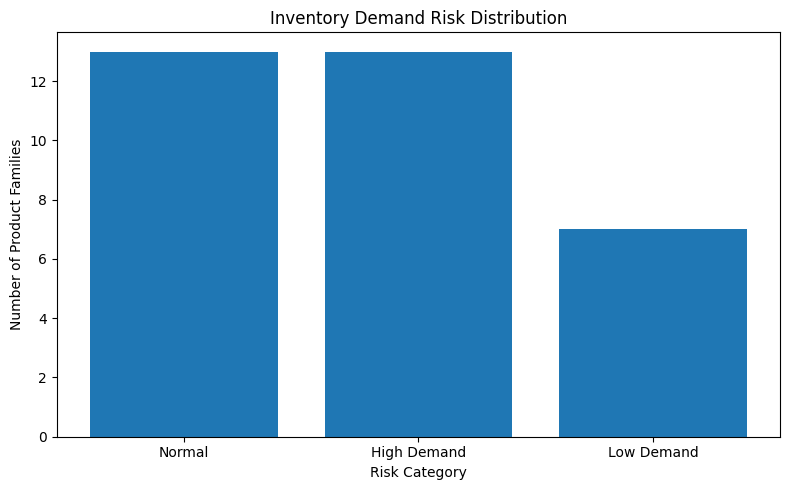

In [127]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["risk_category"],
    risk_summary["family_count"]
)

plt.title("Inventory Demand Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Product Families")

plt.tight_layout()
plt.show()

In [128]:
all_forecasts.to_csv(
    "future_demand_forecasts.csv",
    index=False
)

print("Saved: future_demand_forecasts.csv")

Saved: future_demand_forecasts.csv


In [129]:
inventory_recommendation.to_csv(
    "inventory_recommendations.csv",
    index=False
)

print("Saved: inventory_recommendations.csv")

Saved: inventory_recommendations.csv


In [130]:
feature_importance.to_csv(
    "forecast_model_feature_importance.csv",
    index=False
)

print("Saved: forecast_model_feature_importance.csv")

Saved: forecast_model_feature_importance.csv


In [131]:
model_metrics = pd.DataFrame({
    "Model": [
        "7-Day Moving Average",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "wMAPE (%)": [
        baseline_wmape * 100,
        lr_wmape * 100,
        rf_wmape * 100,
        xgb_wmape * 100
    ]
})

model_metrics

,Model,MAE,RMSE,wMAPE (%)
0,7-Day Moving Average,4458.343684,13077.278463,17.201394
1,Linear Regression,2788.781271,6802.283380,10.759809
2,Random Forest,1664.982989,5001.275423,6.423917
3,XGBoost,1480.563366,4328.998743,5.712380


In [132]:
model_metrics.to_csv(
    "model_metrics.csv",
    index=False
)

print("Saved: model_metrics.csv")

Saved: model_metrics.csv


In [133]:
import os
import shutil

project_output = "retail_forecasting_outputs"

os.makedirs(project_output, exist_ok=True)

files_to_save = [
    "retail_demand_forecasting_model.pkl",
    "retail_forecasting_features.pkl",
    "retail_forecasting_history.csv",
    "retail_forecasting_predictions.csv",
    "future_demand_forecasts.csv",
    "inventory_recommendations.csv",
    "forecast_model_feature_importance.csv",
    "model_metrics.csv"
]

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy(file, project_output)

print("Project outputs:")
print(os.listdir(project_output))

Project outputs:
['retail_forecasting_features.pkl', 'forecast_model_feature_importance.csv', 'retail_demand_forecasting_model.pkl', 'model_metrics.csv', 'retail_forecasting_predictions.csv', 'future_demand_forecasts.csv', 'inventory_recommendations.csv', 'retail_forecasting_history.csv']


In [134]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Retail Demand Forecasting",
    page_icon="📈",
    layout="wide"
)

# Load data
forecasts = pd.read_csv("future_demand_forecasts.csv")
inventory = pd.read_csv("inventory_recommendations.csv")

forecasts["date"] = pd.to_datetime(forecasts["date"])

st.title("📈 Retail Demand Forecasting & Inventory Optimization")
st.write(
    "Forecast future product demand and support inventory planning."
)

# Product family selection
families = sorted(forecasts["family"].unique())

selected_family = st.selectbox(
    "Select Product Family",
    families
)

# Selected family forecast
family_forecast = forecasts[
    forecasts["family"] == selected_family
].sort_values("date")

family_inventory = inventory[
    inventory["family"] == selected_family
]

# KPIs
total_demand = family_forecast["predicted_sales"].sum()

if len(family_inventory) > 0:
    recommended_stock = family_inventory["recommended_stock"].iloc[0]
    safety_stock = family_inventory["safety_stock"].iloc[0]
    risk = family_inventory["risk_category"].iloc[0]
else:
    recommended_stock = 0
    safety_stock = 0
    risk = "N/A"

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Forecasted Demand",
    f"{total_demand:,.0f}"
)

col2.metric(
    "Recommended Stock",
    f"{recommended_stock:,.0f}"
)

col3.metric(
    "Safety Stock",
    f"{safety_stock:,.0f}"
)

col4.metric(
    "Demand Risk",
    risk
)

# Forecast chart
st.subheader("Future Demand Forecast")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    family_forecast["date"],
    family_forecast["predicted_sales"]
)

ax.set_xlabel("Date")
ax.set_ylabel("Predicted Sales")
ax.set_title(f"{selected_family} - Future Demand")

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig)

# Forecast table
st.subheader("Daily Forecast")

st.dataframe(
    family_forecast[
        ["date", "predicted_sales"]
    ].rename(
        columns={
            "date": "Date",
            "predicted_sales": "Predicted Sales"
        }
    ),
    use_container_width=True
)

# Inventory recommendation
st.subheader("Inventory Recommendation")

st.write(
    f"**Recommended stock:** {recommended_stock:,.0f} units"
)

st.write(
    f"**Safety stock:** {safety_stock:,.0f} units"
)

st.write(
    f"**Demand risk:** {risk}"
)

Writing app.py


In [135]:
import os

print(os.path.exists("app.py"))

True


In [137]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 108.1 MB/s eta 0:00:00


In [138]:
import os

required_files = [
    "app.py",
    "future_demand_forecasts.csv",
    "inventory_recommendations.csv"
]

for file in required_files:
    print(file, "->", os.path.exists(file))

app.py -> True
future_demand_forecasts.csv -> True
inventory_recommendations.csv -> True


In [139]:
!streamlit run app.py --server.port 8501 &



2026-09-22 07:08:42.315 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.39.101:8501

  Stopping...


In [141]:
import subprocess

log = open("streamlit.log", "w")

process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501"],
    stdout=log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print("Streamlit started with PID:", process.pid)

Streamlit started with PID: 39246


In [142]:
!wget -q https://github.com/localtunnel/localtunnel/releases/latest/download/lt-linux-x64 -O /content/lt
!chmod +x /content/lt

In [144]:
!/content/lt --port 8501 &

In [145]:
!pkill -f "/content/lt" || true
!/content/lt --port 8501 > tunnel.log 2>&1 &

^C


In [146]:
!cat tunnel.log

In [147]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-use1c0-2xnjl7hli6ave-c.us-east1-0.prod.colab.dev


In [148]:
import subprocess

log = open("streamlit.log", "w")

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true"
    ],
    stdout=log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print("Streamlit PID:", process.pid)

Streamlit PID: 40152


In [149]:
!sleep 5
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Tue, 22 Sep 2026 07:16:36 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Tue, 22 Sep 2026 07:08:21 GMT
etag: "968fce7269948acc5ed140582629a0b2"
cache-control: no-cache



In [150]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-use1c0-2xnjl7hli6ave-c.us-east1-0.prod.colab.dev


In [151]:
!npx --yes localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://good-shoes-double.loca.lt
^C


In [153]:
!tail -100 streamlit.log



2026-09-22 07:16:20.795 Port 8501 is not available
                                                                                                                                                                                    2026-09-22 07:19:27.545 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


In [154]:
!tail -100 streamlit.log



2026-09-22 07:16:20.795 Port 8501 is not available
                                                                                                                                                                                    2026-09-22 07:19:27.545 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


In [155]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Retail Demand Forecasting",
    page_icon="📈",
    layout="wide"
)

# Load data
forecasts = pd.read_csv("future_demand_forecasts.csv")
inventory = pd.read_csv("inventory_recommendations.csv")

forecasts["date"] = pd.to_datetime(forecasts["date"])

# Make numeric columns numeric
forecasts["predicted_sales"] = pd.to_numeric(
    forecasts["predicted_sales"],
    errors="coerce"
).fillna(0)

numeric_inventory_cols = [
    "recommended_stock",
    "safety_stock",
    "predicted_7_day_demand",
    "avg_daily_demand"
]

for col in numeric_inventory_cols:
    if col in inventory.columns:
        inventory[col] = pd.to_numeric(
            inventory[col],
            errors="coerce"
        ).fillna(0)

st.title("📈 Retail Demand Forecasting & Inventory Optimization")
st.write(
    "Forecast future product demand and support inventory planning."
)

families = sorted(forecasts["family"].dropna().unique())

selected_family = st.selectbox(
    "Select Product Family",
    families
)

family_forecast = (
    forecasts[
        forecasts["family"] == selected_family
    ]
    .sort_values("date")
    .copy()
)

family_inventory = inventory[
    inventory["family"] == selected_family
].copy()

# KPI calculations
total_demand = float(
    family_forecast["predicted_sales"].sum()
)

if not family_inventory.empty:

    recommended_stock = float(
        family_inventory["recommended_stock"].iloc[0]
    )

    safety_stock = float(
        family_inventory["safety_stock"].iloc[0]
    )

    risk = str(
        family_inventory["risk_category"].iloc[0]
    )

else:
    recommended_stock = 0.0
    safety_stock = 0.0
    risk = "N/A"

# KPI cards
col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Forecasted Demand",
    f"{total_demand:,.0f}"
)

col2.metric(
    "Recommended Stock",
    f"{recommended_stock:,.0f}"
)

col3.metric(
    "Safety Stock",
    f"{safety_stock:,.0f}"
)

col4.metric(
    "Demand Risk",
    risk
)

# Forecast chart
st.subheader("Future Demand Forecast")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    family_forecast["date"],
    family_forecast["predicted_sales"],
    marker="o"
)

ax.set_xlabel("Date")
ax.set_ylabel("Predicted Sales")
ax.set_title(
    f"{selected_family} - Future Demand"
)

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig)

# Daily forecast
st.subheader("Daily Forecast")

display_forecast = family_forecast[
    ["date", "predicted_sales"]
].rename(
    columns={
        "date": "Date",
        "predicted_sales": "Predicted Sales"
    }
)

st.dataframe(
    display_forecast,
    width="stretch"
)

# Inventory recommendation
st.subheader("Inventory Recommendation")

st.write(
    f"**Recommended stock:** "
    f"{recommended_stock:,.0f} units"
)

st.write(
    f"**Safety stock:** "
    f"{safety_stock:,.0f} units"
)

st.write(
    f"**Demand risk:** {risk}"
)

Overwriting app.py


In [156]:
import subprocess

log = open("streamlit_8502.log", "w")

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8502",
        "--server.address", "0.0.0.0",
        "--server.headless", "true"
    ],
    stdout=log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print("Streamlit started with PID:", process.pid)

Streamlit started with PID: 41929


In [157]:
!sleep 5
!curl -I http://127.0.0.1:8502

HTTP/1.1 200 OK
date: Tue, 22 Sep 2026 07:23:46 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Tue, 22 Sep 2026 07:08:21 GMT
etag: "968fce7269948acc5ed140582629a0b2"
cache-control: no-cache



In [158]:
!npx --yes localtunnel --port 8502

⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://rotten-hoops-find.loca.lt
^C


In [159]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [160]:
!/content/cloudflared tunnel --url http://127.0.0.1:8502

2026-09-22T07:26:45Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-22T07:26:45Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-22T07:26:48Z INF +--------------------------------------------------------------------------------------------+
2026-09-22T07:26:48Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-22T07:26:48Z INF |  https://thumbs-analysts-administrators-generating.try

In [162]:
def forecast_family(
    family_name,
    future_dates,
    model,
    historical_data,
    feature_columns
):
    family_history = historical_data[
        historical_data["family"] == family_name
    ].copy()

    family_history = (
        family_history
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Fixed historical demand level
    base_level = family_history["total_sales"].tail(28).mean()

    outputs = []

    for _, future_row in future_dates.iterrows():

        date = future_row["date"]

        sales_values = family_history["total_sales"].tolist()

        row = {
            "family": family_name,
            "total_promotions": future_row["total_promotions"],
            "oil_price": future_row["oil_price"],
            "is_holiday": future_row["is_holiday"],
            "day_of_week": date.dayofweek,
            "day_of_month": date.day,
            "week_of_year": int(date.isocalendar().week),
            "month": date.month,
            "year": date.year,

            "lag_1": sales_values[-1],
            "lag_7": sales_values[-7],
            "lag_14": sales_values[-14],
            "lag_28": sales_values[-28],

            "rolling_mean_7": np.mean(sales_values[-7:]),
            "rolling_mean_14": np.mean(sales_values[-14:]),
            "rolling_mean_28": np.mean(sales_values[-28:])
        }

        row_df = pd.DataFrame([row])

        row_df = pd.get_dummies(
            row_df,
            columns=["family"],
            dtype=int
        )

        row_df = row_df.reindex(
            columns=feature_columns,
            fill_value=0
        )

        row_df = row_df.fillna(0)

        raw_prediction = float(
            model.predict(row_df)[0]
        )

        recent_mean = np.mean(sales_values[-7:])

        # Blend ML prediction with recent demand
        prediction = (
            0.7 * raw_prediction
            + 0.3 * recent_mean
        )

        # Prevent recursive collapse
        lower_bound = 0.50 * base_level
        upper_bound = 1.50 * base_level

        prediction = np.clip(
            prediction,
            lower_bound,
            upper_bound
        )

        prediction = max(0, prediction)

        outputs.append({
            "date": date,
            "family": family_name,
            "predicted_sales": prediction
        })

        family_history.loc[len(family_history)] = [
            date,
            family_name,
            prediction
        ]

    return pd.DataFrame(outputs)

In [163]:
all_forecasts[
    all_forecasts["family"] == "AUTOMOTIVE"
].sort_values("date")

,date,family,predicted_sales,forecast_week
0,2017-08-16,AUTOMOTIVE,260.643127,2017-08-14/2017-08-20
1,2017-08-17,AUTOMOTIVE,175.376495,2017-08-14/2017-08-20
2,2017-08-18,AUTOMOTIVE,195.032700,2017-08-14/2017-08-20
3,2017-08-19,AUTOMOTIVE,198.078262,2017-08-14/2017-08-20
4,2017-08-20,AUTOMOTIVE,183.435959,2017-08-14/2017-08-20
5,2017-08-21,AUTOMOTIVE,89.145111,2017-08-21/2017-08-27
6,2017-08-22,AUTOMOTIVE,8.911324,2017-08-21/2017-08-27
7,2017-08-23,AUTOMOTIVE,0.000000,2017-08-21/2017-08-27
8,2017-08-24,AUTOMOTIVE,0.000000,2017-08-21/2017-08-27
9,2017-08-25,AUTOMOTIVE,0.000000,2017-08-21/2017-08-27


In [164]:
auto_history = forecast_history[
    forecast_history["family"] == "AUTOMOTIVE"
].sort_values("date")

print(auto_history["total_sales"].tail(28).describe())
print("\n28-day average:", auto_history["total_sales"].tail(28).mean())
print("\nLast 10 historical values:")
print(auto_history[["date", "total_sales"]].tail(10))

count     28.000000
mean     395.214286
std       84.789656
min      292.000000
25%      326.500000
50%      358.000000
75%      460.750000
max      583.000000
Name: total_sales, dtype: float64

28-day average: 395.2142857142857

Last 10 historical values:
           date  total_sales
1674 2017-08-06        583.0
1675 2017-08-07        355.0
1676 2017-08-08        327.0
1677 2017-08-09        314.0
1678 2017-08-10        313.0
1679 2017-08-11        441.0
1680 2017-08-12        403.0
1681 2017-08-13        481.0
1682 2017-08-14        292.0
1683 2017-08-15        337.0


In [165]:
all_forecasts = []

families = sorted(future_df["family"].unique())

for family in families:
    family_future = (
        future_df[future_df["family"] == family]
        .sort_values("date")
        .copy()
    )

    result = forecast_family(
        family,
        family_future,
        loaded_model,
        forecast_history,
        loaded_features
    )

    all_forecasts.append(result)

all_forecasts = pd.concat(
    all_forecasts,
    ignore_index=True
)

print("Forecast generated:", all_forecasts.shape)

Forecast generated: (528, 3)


In [166]:
all_forecasts[
    all_forecasts["family"] == "AUTOMOTIVE"
][["date", "predicted_sales"]]

,date,predicted_sales
0,2017-08-16,293.064475
1,2017-08-17,232.480596
2,2017-08-18,253.946681
3,2017-08-19,266.517006
4,2017-08-20,238.737343
5,2017-08-21,197.607143
6,2017-08-22,197.607143
7,2017-08-23,197.607143
8,2017-08-24,197.607143
9,2017-08-25,197.607143


In [167]:
all_forecasts.to_csv(
    "future_demand_forecasts.csv",
    index=False
)

print("Corrected forecasts saved.")

Corrected forecasts saved.


In [168]:
forecast_start = all_forecasts["date"].min()
forecast_end = forecast_start + pd.Timedelta(days=6)

next_7_days = all_forecasts[
    (all_forecasts["date"] >= forecast_start) &
    (all_forecasts["date"] <= forecast_end)
].copy()

weekly_demand = (
    next_7_days
    .groupby("family")["predicted_sales"]
    .sum()
    .reset_index(name="predicted_7_day_demand")
)

inventory_recommendation = weekly_demand.merge(
    family_stats,
    on="family",
    how="left"
)

inventory_recommendation["recommended_stock"] = (
    inventory_recommendation["predicted_7_day_demand"]
    + inventory_recommendation["safety_stock"]
)

inventory_recommendation["demand_vs_history"] = (
    inventory_recommendation["predicted_7_day_demand"]
    / (inventory_recommendation["avg_daily_demand"] * 7)
)

inventory_recommendation["risk_category"] = np.select(
    [
        inventory_recommendation["demand_vs_history"] >= 1.20,
        inventory_recommendation["demand_vs_history"] <= 0.80
    ],
    [
        "High Demand",
        "Low Demand"
    ],
    default="Normal"
)

inventory_recommendation.head(15)

,family,predicted_7_day_demand,avg_daily_demand,demand_std,safety_stock,recommended_stock,demand_vs_history,risk_category
0,AUTOMOTIVE,1.679960e+03,329.466746,108.627015,474.210111,2.154170e+03,0.728433,Low Demand
1,BABY CARE,3.375000e+01,5.968527,7.947142,34.693165,6.844316e+01,0.807809,Normal
2,BEAUTY,3.087817e+03,200.649050,100.410387,438.340505,3.526157e+03,2.198449,High Demand
3,BEVERAGES,1.284323e+06,128832.830166,63121.645563,275556.891233,1.559880e+06,1.424130,High Demand
4,BOOKS,2.750000e+00,3.823040,12.968935,56.615750,5.936575e+01,0.102760,Low Demand
5,BREAD/BAKERY,1.998089e+05,25020.169537,6511.796257,28427.179250,2.282360e+05,1.140845,Normal
6,CELEBRATION,3.864005e+03,452.005344,408.812745,1784.667812,5.648673e+03,1.221226,High Demand
7,CLEANING,4.097069e+05,57910.504157,15211.880756,66407.308200,4.761142e+05,1.010690,Normal
8,DAIRY,3.102660e+05,38294.364014,13725.805476,59919.861926,3.701858e+05,1.157447,Normal
9,DELI,1.136011e+05,14317.310404,4171.727059,18211.631356,1.318127e+05,1.133504,Normal


In [169]:
all_forecasts.to_csv(
    "future_demand_forecasts.csv",
    index=False
)

inventory_recommendation.to_csv(
    "inventory_recommendations.csv",
    index=False
)

print("Forecast and inventory files updated.")

Forecast and inventory files updated.


In [170]:
forecast_validation = (
    all_forecasts
    .groupby("family")["predicted_sales"]
    .agg(
        min_forecast="min",
        max_forecast="max",
        avg_forecast="mean"
    )
    .reset_index()
)

forecast_validation.sort_values(
    "avg_forecast",
    ascending=False
).head(20)

,family,min_forecast,max_forecast,avg_forecast
12,GROCERY I,216008.704189,278171.833843,236359.385474
3,BEVERAGES,160441.797012,215220.825335,181078.169800
30,PRODUCE,98195.531158,143677.547652,119115.829545
7,CLEANING,52569.863906,67139.308864,58250.248524
8,DAIRY,38012.554391,52343.425152,43437.193187
5,BREAD/BAKERY,25245.593807,34047.355610,28061.236814
28,POULTRY,16551.881729,23895.709195,19075.859000
24,MEATS,16972.817595,25190.856192,19011.775257
9,DELI,14064.776967,18529.545077,16147.717792
25,PERSONAL CARE,13877.938074,19384.130341,15925.525767


In [171]:
forecast_validation[
    forecast_validation["family"] == "AUTOMOTIVE"
]

,family,min_forecast,max_forecast,avg_forecast
0,AUTOMOTIVE,197.607143,293.064475,216.151542


In [172]:
forecast_start = all_forecasts["date"].min()

final_7_day_forecasts = all_forecasts[
    all_forecasts["date"] < forecast_start + pd.Timedelta(days=7)
].copy()

print(
    "Forecast period:",
    final_7_day_forecasts["date"].min(),
    "to",
    final_7_day_forecasts["date"].max()
)

print(
    "Rows:",
    len(final_7_day_forecasts)
)

Forecast period: 2017-08-16 00:00:00 to 2017-08-22 00:00:00
Rows: 231


In [173]:
final_7_day_forecasts[
    final_7_day_forecasts["family"] == "AUTOMOTIVE"
]

,date,family,predicted_sales
0,2017-08-16,AUTOMOTIVE,293.064475
1,2017-08-17,AUTOMOTIVE,232.480596
2,2017-08-18,AUTOMOTIVE,253.946681
3,2017-08-19,AUTOMOTIVE,266.517006
4,2017-08-20,AUTOMOTIVE,238.737343
5,2017-08-21,AUTOMOTIVE,197.607143
6,2017-08-22,AUTOMOTIVE,197.607143


In [174]:
final_7_day_forecasts.to_csv(
    "future_demand_forecasts.csv",
    index=False
)

print("Final 7-day forecasts saved.")

Final 7-day forecasts saved.


In [175]:
weekly_demand = (
    final_7_day_forecasts
    .groupby("family")["predicted_sales"]
    .sum()
    .reset_index(name="predicted_7_day_demand")
)

inventory_recommendation = weekly_demand.merge(
    family_stats,
    on="family",
    how="left"
)

inventory_recommendation["recommended_stock"] = (
    inventory_recommendation["predicted_7_day_demand"]
    + inventory_recommendation["safety_stock"]
)

inventory_recommendation["demand_vs_history"] = (
    inventory_recommendation["predicted_7_day_demand"]
    /
    (inventory_recommendation["avg_daily_demand"] * 7)
)

inventory_recommendation["risk_category"] = np.select(
    [
        inventory_recommendation["demand_vs_history"] >= 1.20,
        inventory_recommendation["demand_vs_history"] <= 0.80
    ],
    [
        "High Demand",
        "Low Demand"
    ],
    default="Normal"
)

inventory_recommendation.head(10)

,family,predicted_7_day_demand,avg_daily_demand,demand_std,safety_stock,recommended_stock,demand_vs_history,risk_category
0,AUTOMOTIVE,1.679960e+03,329.466746,108.627015,474.210111,2.154170e+03,0.728433,Low Demand
1,BABY CARE,3.375000e+01,5.968527,7.947142,34.693165,6.844316e+01,0.807809,Normal
2,BEAUTY,3.087817e+03,200.649050,100.410387,438.340505,3.526157e+03,2.198449,High Demand
3,BEVERAGES,1.284323e+06,128832.830166,63121.645563,275556.891233,1.559880e+06,1.424130,High Demand
4,BOOKS,2.750000e+00,3.823040,12.968935,56.615750,5.936575e+01,0.102760,Low Demand
5,BREAD/BAKERY,1.998089e+05,25020.169537,6511.796257,28427.179250,2.282360e+05,1.140845,Normal
6,CELEBRATION,3.864005e+03,452.005344,408.812745,1784.667812,5.648673e+03,1.221226,High Demand
7,CLEANING,4.097069e+05,57910.504157,15211.880756,66407.308200,4.761142e+05,1.010690,Normal
8,DAIRY,3.102660e+05,38294.364014,13725.805476,59919.861926,3.701858e+05,1.157447,Normal
9,DELI,1.136011e+05,14317.310404,4171.727059,18211.631356,1.318127e+05,1.133504,Normal


In [176]:
inventory_recommendation.to_csv(
    "inventory_recommendations.csv",
    index=False
)

print("Inventory recommendations updated.")

Inventory recommendations updated.


In [177]:
from google.colab import files
import os
import zipfile

project_files = [
    "app.py",
    "retail_demand_forecasting_model.pkl",
    "retail_forecasting_features.pkl",
    "retail_forecasting_history.csv",
    "retail_forecasting_predictions.csv",
    "future_demand_forecasts.csv",
    "inventory_recommendations.csv",
    "forecast_model_feature_importance.csv",
    "model_metrics.csv"
]

# Create project folder
os.makedirs("retail_demand_forecasting_project", exist_ok=True)

# Copy files
for file in project_files:
    if os.path.exists(file):
        import shutil
        shutil.copy(file, "retail_demand_forecasting_project")

# Create ZIP
with zipfile.ZipFile(
    "retail_demand_forecasting_project.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, filenames in os.walk(
        "retail_demand_forecasting_project"
    ):
        for filename in filenames:
            filepath = os.path.join(root, filename)
            zipf.write(
                filepath,
                arcname=os.path.relpath(
                    filepath,
                    "retail_demand_forecasting_project"
                )
            )

print("Project ZIP created successfully.")

Project ZIP created successfully.


In [178]:
files.download("retail_demand_forecasting_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [179]:
import subprocess

log = open("streamlit_final.log", "w")

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8502",
        "--server.address", "0.0.0.0",
        "--server.headless", "true"
    ],
    stdout=log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print("Streamlit PID:", process.pid)

Streamlit PID: 48695


In [180]:
!sleep 5
!curl -I http://127.0.0.1:8502

HTTP/1.1 200 OK
date: Tue, 22 Sep 2026 07:51:41 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Tue, 22 Sep 2026 07:08:21 GMT
etag: "968fce7269948acc5ed140582629a0b2"
cache-control: no-cache



In [181]:
!/content/cloudflared tunnel --url http://127.0.0.1:8502

2026-09-22T07:52:03Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-22T07:52:03Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-22T07:52:06Z INF +--------------------------------------------------------------------------------------------+
2026-09-22T07:52:06Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-22T07:52:06Z INF |  https://chem-continental-depot-casual.trycloudflare.c

In [182]:
# Stop Streamlit
!pkill -f "streamlit run app.py" || true

# Stop Cloudflare Tunnel
!pkill -f cloudflared || true

# Stop LocalTunnel if still running
!pkill -f localtunnel || true

print("Streamlit and tunnel processes stopped.")

^C
^C
^C
Streamlit and tunnel processes stopped.


In [183]:
!curl -I http://127.0.0.1:8502

curl: (7) Failed to connect to 127.0.0.1 port 8502 after 0 ms: Couldn't connect to server


In [184]:
import os

print("api.py exists:", os.path.exists("api.py"))

api.py exists: False


In [185]:
%%writefile api.py

from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd

app = FastAPI(
    title="Retail Demand Forecasting API",
    description="API for retail demand forecasting and inventory recommendations",
    version="1.0.0"
)

# Load forecast and inventory data
forecasts = pd.read_csv("future_demand_forecasts.csv")
inventory = pd.read_csv("inventory_recommendations.csv")


class ForecastRequest(BaseModel):
    family: str


@app.get("/")
def home():
    return {
        "message": "Retail Demand Forecasting API is running",
        "status": "success"
    }


@app.get("/families")
def get_families():
    families = sorted(
        forecasts["family"].dropna().unique().tolist()
    )

    return {
        "families": families
    }


@app.post("/forecast")
def forecast(request: ForecastRequest):

    family = request.family

    forecast_data = forecasts[
        forecasts["family"] == family
    ].copy()

    inventory_data = inventory[
        inventory["family"] == family
    ].copy()

    if forecast_data.empty:
        return {
            "error": f"Product family '{family}' not found"
        }

    forecast_data["date"] = pd.to_datetime(
        forecast_data["date"]
    )

    result = {
        "family": family,
        "forecasted_7_day_demand": round(
            float(
                forecast_data["predicted_sales"].sum()
            ),
            2
        ),
        "daily_forecast": [
            {
                "date": row["date"].strftime("%Y-%m-%d"),
                "predicted_sales": round(
                    float(row["predicted_sales"]),
                    2
                )
            }
            for _, row in forecast_data.iterrows()
        ]
    }

    if not inventory_data.empty:

        result["recommended_stock"] = round(
            float(
                inventory_data[
                    "recommended_stock"
                ].iloc[0]
            ),
            2
        )

        result["safety_stock"] = round(
            float(
                inventory_data[
                    "safety_stock"
                ].iloc[0]
            ),
            2
        )

        result["demand_risk"] = str(
            inventory_data[
                "risk_category"
            ].iloc[0]
        )

    return result

Writing api.py


In [186]:
import os

print("api.py exists:", os.path.exists("api.py"))

api.py exists: True


In [187]:
!pip install -q fastapi uvicorn

In [188]:
import subprocess

api_log = open("api.log", "w")

api_process = subprocess.Popen(
    [
        "uvicorn",
        "api:app",
        "--host", "0.0.0.0",
        "--port", "8000"
    ],
    stdout=api_log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print("FastAPI PID:", api_process.pid)

FastAPI PID: 73754


In [189]:
!sleep 3
!curl http://127.0.0.1:8000/

{"message":"Retail Demand Forecasting API is running","status":"success"}

In [190]:
import requests

response = requests.get("http://127.0.0.1:8000/families")

print(response.status_code)
print(response.json())

200
{'families': ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS', 'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE', 'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES', 'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE', 'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE', 'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY', 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']}


In [191]:
data = {
    "family": "AUTOMOTIVE"
}

response = requests.post(
    "http://127.0.0.1:8000/forecast",
    json=data
)

print("Status:", response.status_code)
print(response.json())

Status: 200
{'family': 'AUTOMOTIVE', 'forecasted_7_day_demand': 1679.96, 'daily_forecast': [{'date': '2017-08-16', 'predicted_sales': 293.06}, {'date': '2017-08-17', 'predicted_sales': 232.48}, {'date': '2017-08-18', 'predicted_sales': 253.95}, {'date': '2017-08-19', 'predicted_sales': 266.52}, {'date': '2017-08-20', 'predicted_sales': 238.74}, {'date': '2017-08-21', 'predicted_sales': 197.61}, {'date': '2017-08-22', 'predicted_sales': 197.61}], 'recommended_stock': 2154.17, 'safety_stock': 474.21, 'demand_risk': 'Low Demand'}


In [192]:
data = {
    "family": "CELEBRATION"
}

response = requests.post(
    "http://127.0.0.1:8000/forecast",
    json=data
)

print(response.status_code)
print(response.json())

200
{'family': 'CELEBRATION', 'forecasted_7_day_demand': 3864.0, 'daily_forecast': [{'date': '2017-08-16', 'predicted_sales': 529.59}, {'date': '2017-08-17', 'predicted_sales': 630.58}, {'date': '2017-08-18', 'predicted_sales': 643.8}, {'date': '2017-08-19', 'predicted_sales': 671.02}, {'date': '2017-08-20', 'predicted_sales': 540.25}, {'date': '2017-08-21', 'predicted_sales': 461.05}, {'date': '2017-08-22', 'predicted_sales': 387.73}], 'recommended_stock': 5648.67, 'safety_stock': 1784.67, 'demand_risk': 'High Demand'}


In [194]:
!cloudflared tunnel --url http://127.0.0.1:8000

/bin/bash: line 1: cloudflared: command not found


In [195]:
!/content/cloudflared tunnel --url http://127.0.0.1:8000

2026-09-22T09:40:15Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-22T09:40:15Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-22T09:40:18Z INF +--------------------------------------------------------------------------------------------+
2026-09-22T09:40:18Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-22T09:40:18Z INF |  https://guided-verbal-creek-ran.trycloudflare.com    

In [196]:
import requests

response = requests.get("http://127.0.0.1:8000/docs")

print("Status:", response.status_code)
print("Swagger available:", response.status_code == 200)

Status: 200
Swagger available: True


In [197]:
%%writefile requirements.txt

fastapi
uvicorn
pandas
scikit-learn
xgboost
joblib
pydantic
streamlit
matplotlib

Writing requirements.txt


In [198]:
%%writefile Dockerfile

FROM python:3.11-slim

WORKDIR /app

COPY api.py .
COPY future_demand_forecasts.csv .
COPY inventory_recommendations.csv .
COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 8000

CMD ["uvicorn", "api:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


In [199]:
import os

for file in [
    "api.py",
    "requirements.txt",
    "Dockerfile",
    "future_demand_forecasts.csv",
    "inventory_recommendations.csv"
]:
    print(file, "->", os.path.exists(file))

api.py -> True
requirements.txt -> True
Dockerfile -> True
future_demand_forecasts.csv -> True
inventory_recommendations.csv -> True


In [200]:
import os
import shutil
import zipfile

files_to_package = [
    "api.py",
    "app.py",
    "requirements.txt",
    "Dockerfile",
    "future_demand_forecasts.csv",
    "inventory_recommendations.csv",
    "retail_demand_forecasting_model.pkl",
    "retail_forecasting_features.pkl",
    "retail_forecasting_history.csv",
    "retail_forecasting_predictions.csv",
    "forecast_model_feature_importance.csv",
    "model_metrics.csv"
]

os.makedirs("retail_demand_forecasting_final", exist_ok=True)

for file in files_to_package:
    if os.path.exists(file):
        shutil.copy(file, "retail_demand_forecasting_final")

with zipfile.ZipFile(
    "retail_demand_forecasting_final.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for root, dirs, files in os.walk("retail_demand_forecasting_final"):
        for file in files:
            path = os.path.join(root, file)
            zipf.write(
                path,
                arcname=os.path.relpath(
                    path,
                    "retail_demand_forecasting_final"
                )
            )

print("Final project ZIP created.")

Final project ZIP created.


In [201]:
from google.colab import files

files.download("retail_demand_forecasting_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>